In [169]:
 pip -q install git+https://github.com/alok-ai-lab/pyDeepInsight.git#egg=pyDeepInsight

Note: you may need to restart the kernel to use updated packages.


In [170]:
 pip install umap-learn

In [171]:
pip install timm

Note: you may need to restart the kernel to use updated packages.


In [1]:
#STEP-01 Loading all libraries
from pyDeepInsight import ImageTransformer, CAMFeatureSelector
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split # spliting data into training and testing sets
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Check accuracy score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import umap.umap_ as umap
import torch
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score
from IPython.display import display, clear_output
import os
import timm
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier # Random Forest classifier
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
#STEP-02
# Loading dataset & display the first few rows of the dataframe
df = pd.read_csv('SDN20_Shuffled.csv')

In [3]:
# Assuming our labels are in a column named 'multilabel' cosidering normal as 0 and rest anomalous as 1
#df['project'] = df['project'].apply(lambda x: 0 if x == 'BRCA' else 1)
df.shape

(205167, 78)

In [4]:
df.columns

Index(['Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Size Avg', 'Bwd

In [5]:
df.fillna(0, inplace=True)

df_y=df['multilabel']

df_x=df.drop(labels=['multilabel'], axis=1)

In [6]:
pd.options.display.max_rows = 100
df_x.dtypes

Protocol               int64
Flow Duration          int64
Tot Fwd Pkts           int64
Tot Bwd Pkts           int64
TotLen Fwd Pkts        int64
TotLen Bwd Pkts        int64
Fwd Pkt Len Max        int64
Fwd Pkt Len Min        int64
Fwd Pkt Len Mean     float64
Fwd Pkt Len Std      float64
Bwd Pkt Len Max        int64
Bwd Pkt Len Min        int64
Bwd Pkt Len Mean     float64
Bwd Pkt Len Std      float64
Flow Byts/s          float64
Flow Pkts/s          float64
Flow IAT Mean        float64
Flow IAT Std         float64
Flow IAT Max           int64
Flow IAT Min           int64
Fwd IAT Tot            int64
Fwd IAT Mean         float64
Fwd IAT Std          float64
Fwd IAT Max            int64
Fwd IAT Min            int64
Bwd IAT Tot            int64
Bwd IAT Mean         float64
Bwd IAT Std          float64
Bwd IAT Max            int64
Bwd IAT Min            int64
Fwd PSH Flags          int64
Bwd PSH Flags          int64
Fwd URG Flags          int64
Bwd URG Flags          int64
Fwd Header Len

In [7]:
df_y=pd.DataFrame(df_y)
df_y

,multilabel
0,DDoS
1,DDoS
2,normal
3,normal
4,Probe
...,...
205162,Probe
205163,normal
205164,normal
205165,Probe


In [8]:
df_y.loc[df_y['multilabel'] == 'normal', 'multilabel'] = 0
df_y.loc[df_y['multilabel'] != 0, 'multilabel'] = 1
df_y['multilabel']=df_y['multilabel'].astype(int)

In [9]:
df_y

,multilabel
0,1
1,1
2,0
3,0
4,1
...,...
205162,1
205163,0
205164,0
205165,1


In [10]:
#find categorical data
df_x.nunique()
#maybe categorical: Protocol;Fwd PSH Flags; Bwd PSH Flags; URG Flags; Bwd URG Flags
#ignoring this for now

Protocol                 3
Flow Duration        67502
Tot Fwd Pkts           530
Tot Bwd Pkts           682
TotLen Fwd Pkts       5289
TotLen Bwd Pkts       7495
Fwd Pkt Len Max       2103
Fwd Pkt Len Min         76
Fwd Pkt Len Mean      8479
Fwd Pkt Len Std      10133
Bwd Pkt Len Max       2950
Bwd Pkt Len Min         64
Bwd Pkt Len Mean     10317
Bwd Pkt Len Std      12487
Flow Byts/s          84729
Flow Pkts/s          73249
Flow IAT Mean        74942
Flow IAT Std         72562
Flow IAT Max         36014
Flow IAT Min         14150
Fwd IAT Tot          31575
Fwd IAT Mean         42164
Fwd IAT Std          43915
Fwd IAT Max          30657
Fwd IAT Min          11633
Bwd IAT Tot          34144
Bwd IAT Mean         47609
Bwd IAT Std          45405
Bwd IAT Max          31981
Bwd IAT Min          14196
Fwd PSH Flags            1
Bwd PSH Flags            2
Fwd URG Flags            1
Bwd URG Flags            1
Fwd Header Len         597
Bwd Header Len        1008
Fwd Pkts/s           66303
B

In [11]:
#moving to numpy as it is easier to check columns
np_x=df_x.to_numpy()
identical=np.all(np_x == np_x[0,:], axis = 0)
identical #True means there are some columns that must be dropped

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True, False, False, False,
       False,  True,  True,  True,  True,  True,  True, False, False,
       False, False,  True, False, False,  True, False, False, False,
       False, False, False, False, False])

In [12]:
to_be_deleted=np.where(identical==True)
to_be_deleted

(array([30, 32, 33, 48, 49, 50, 55, 56, 57, 58, 59, 60, 65, 68],
       dtype=int64),)

In [13]:
#deleting column, back to pandas as it is easier
data_pd=pd.DataFrame(np_x)

In [14]:
data_pd.drop(data_pd.columns[to_be_deleted[0]], inplace=True, axis=1)

In [15]:
#back to numpy and normalize
np_x=data_pd.to_numpy()
# normalize each column by subtracting its mean and dividing by its standard deviation
col_means = np.mean(np_x, axis=0)

data_normalized = (np_x - col_means) / np.std(np_x, axis=0)

In [16]:
reducer = umap.UMAP(
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    n_jobs=-1,
    random_state=42

)

pixel_size = (8, 8)
it = ImageTransformer(
    feature_extractor=reducer,
    #feature_extractor='pca',
    pixels=pixel_size)

In [17]:
# STEP-04:
# Spliting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data_normalized, df_y, test_size = 0.2, random_state = 42)

C:\Users\Setha\anaconda3\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


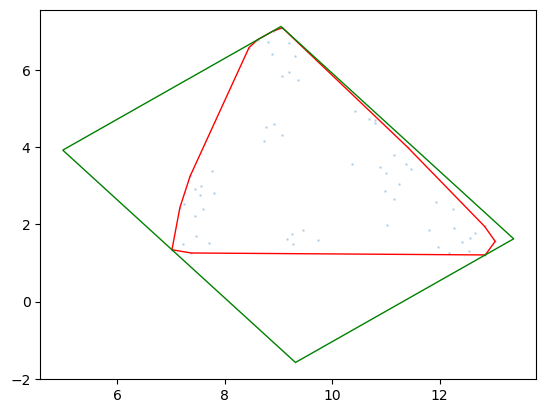

In [18]:
it.fit(X_train, plot=True)

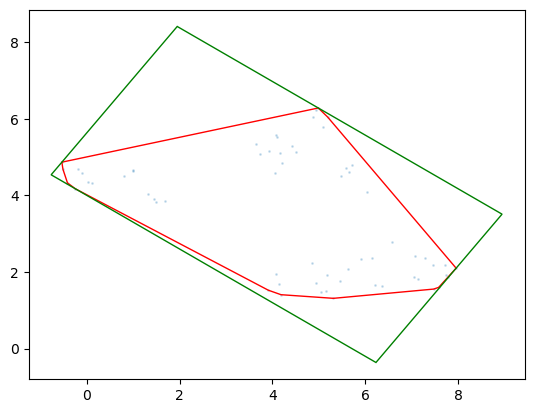

In [19]:
it.fit(X_test, plot=True)

In [20]:
 X_train_img = it.transform(X_train)

In [21]:
 X_train_img.shape

(164133, 8, 8, 3)

In [22]:
 X_test_img = it.transform(X_test)

In [23]:
 X_test_img.shape

(41034, 8, 8, 3)

In [24]:
#probably needs another normalization step for each individual image
#not doing it as it is not relevant for showing images
X_train_img.min(), X_train_img.max()

(-0.7679757152226084, 259.80283258254036)

In [25]:
X_test_img.min(), X_test_img.max()

(-0.7679757152226084, 246.51657158592477)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


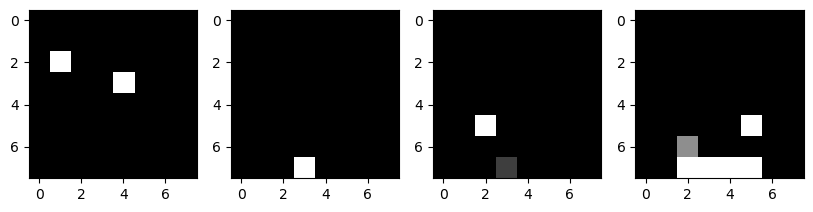

In [26]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 10))

fig.add_subplot(1, 4, 1 )
plt.imshow(X_train_img[2])
fig.add_subplot(1, 4, 2 )
plt.imshow(X_train_img[5])
fig.add_subplot(1, 4, 3 )
plt.imshow(X_train_img[20])
fig.add_subplot(1, 4, 4 )
plt.imshow(X_train_img[55])

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


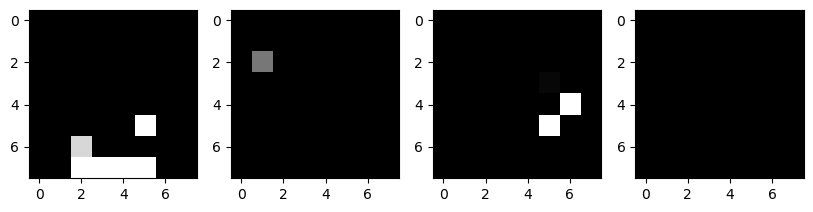

In [27]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 10))

fig.add_subplot(1, 4, 1 )
plt.imshow(X_test_img[2])
fig.add_subplot(1, 4, 2 )
plt.imshow(X_test_img[5])
fig.add_subplot(1, 4, 3 )
plt.imshow(X_test_img[20])
fig.add_subplot(1, 4, 4 )
plt.imshow(X_test_img[55])

plt.show()

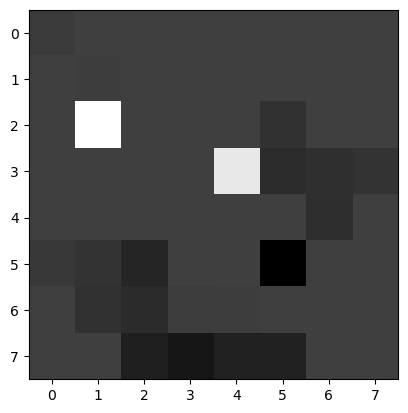

In [28]:
img = (X_train_img[2] - X_train_img[2].min()) / (X_train_img[2].max() - X_train_img[2].min())
plt.imshow(img, cmap='viridis')

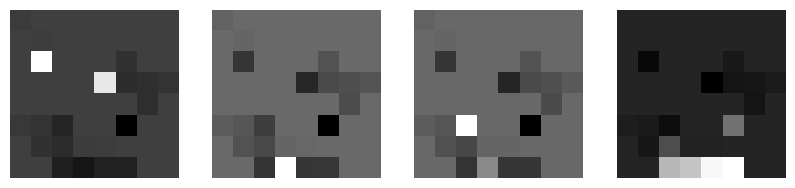

In [126]:
fig = plt.figure(figsize=(10,4))

indices = [2,5,20,55]

for i, idx in enumerate(indices):

    img = X_train_img[idx]
    img = (img - img.min()) / (img.max() - img.min())

    fig.add_subplot(1,4,i+1)
    plt.imshow(img, cmap='viridis')
    plt.axis('off')

plt.show()

In [127]:
plt.figure(figsize=(12,4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

In [29]:
#check similar rows on initial dataframe
sorted=np.sort(X_train)
counter=0
for i in range(0,sorted.shape[0]-1):
  if((sorted[i]==sorted[i+1]).all()):
    counter=counter+1

counter #how many elements are the same

874

In [30]:
#now in the generated dataset
sorted=np.sort(X_train_img)
counter=0
for i in range(0,sorted.shape[0]-1):
  if((sorted[i]==sorted[i+1]).all()):
    counter=counter+1

counter #how many elements are the same

874

In [31]:
#check similar rows on initial dataframe
sorted=np.sort(X_test)
counter=0
for i in range(0,sorted.shape[0]-1):
  if((sorted[i]==sorted[i+1]).all()):
    counter=counter+1

counter #how many elements are the same

186

In [32]:
#now in the generated dataset
sorted=np.sort(X_test_img)
counter=0
for i in range(0,sorted.shape[0]-1):
  if((sorted[i]==sorted[i+1]).all()):
    counter=counter+1

counter #how many elements are the same

186

In [33]:
# Normalizing the image data to the range [0, 1]
X_train_img_normalized = (X_train_img - X_train_img.min()) / (X_train_img.max() - X_train_img.min())
X_test_img_normalized = (X_test_img - X_test_img.min()) / (X_test_img.max() - X_test_img.min())

In [90]:
#Starting DeepSVDD Code from here...
!pip install torch numpy pandas scikit-learn

In [59]:
# Start of the Autoencoder model (AE)

# Defining the Autoencoder model
class Autoencoder(tf.keras.Model):
    def __init__(self, input_shape, latent_dim=64):
        super(Autoencoder, self).__init__()
        self.encoder = self.build_encoder(input_shape, latent_dim)
        self.decoder = self.build_decoder(input_shape, latent_dim)

    # Compresses input data into a smaller latent representation (bottleneck).
    # Captures essential features of the input data.
    def build_encoder(self, input_shape, latent_dim):
        return models.Sequential([
            layers.InputLayer(input_shape=input_shape),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(latent_dim, activation='relu')
        ])

    # Reconstructs the original input data from the latent representation.
    def build_decoder(self, input_shape, latent_dim):
        return models.Sequential([
            layers.Input(shape=(latent_dim,)),
            layers.Dense(input_shape[0] // 4 * input_shape[1] // 4 * 64, activation='relu'),
            layers.Reshape((input_shape[0] // 4, input_shape[1] // 4, 64)),
            layers.Conv2DTranspose(64, (3, 3), activation='relu', strides=2, padding='same'),
            layers.Conv2DTranspose(32, (3, 3), activation='relu', strides=2, padding='same'),
            layers.Conv2DTranspose(input_shape[2], (3, 3), activation='sigmoid', padding='same')
        ])

    def call(self, inputs):
        encoded = self.encoder(inputs)
        decoded = self.decoder(encoded)
        return decoded

In [4]:
# STEP 0: Install
!pip install tensorflow scikit-learn -q

# STEP 1: Imports
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)


# STEP 2: Load + Preprocess
df = pd.read_csv('SDN20_Shuffled.csv')
df.fillna(0, inplace=True)

df_y = (df['multilabel'] != 'normal').astype(int)
df_x = df.drop(columns=['multilabel'])

np_x = df_x.to_numpy()
identical_cols = np.all(np_x == np_x[0, :], axis=0)
df_x = df_x.drop(columns=df_x.columns[identical_cols])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_x)

X_train, X_test, y_train, y_test = train_test_split(
    data_scaled, df_y,
    test_size=0.2,
    random_state=42,
    stratify=df_y
)


# STEP 3: Train Autoencoder
input_dim = X_train.shape[1]

inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)
latent = layers.Dense(32, activation='relu')(x)

x = layers.Dense(64, activation='relu')(latent)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(input_dim)(x)

ae = Model(inputs, outputs)
ae.compile(optimizer=Adam(1e-3), loss='mse')

ae.fit(
    X_train, X_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)


# STEP 4: Extract Latent Features
encoder = Model(ae.input, latent)

X_train_latent = encoder.predict(X_train)
X_test_latent = encoder.predict(X_test)


# STEP 5: Train Classifier
clf = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_latent.shape[1],)),
    layers.Dense(1, activation='sigmoid')
])

clf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = clf.fit(
    X_train_latent, y_train,
    epochs=40,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)


# STEP 6: Training Predictions
train_probs = clf.predict(X_train_latent).ravel()
y_train_pred = (train_probs > 0.5).astype(int)


# STEP 7: Testing Predictions
test_probs = clf.predict(X_test_latent).ravel()
y_test_pred = (test_probs > 0.5).astype(int)


# STEP 8: Training Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)


# STEP 9: Testing Metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, test_probs)


# STEP 10: Print Results
print("\nAutoencoder trained on normal images + attacks (2-Class)")

print("\n----- TRAINING METRICS -----")
print("Training Accuracy:", round(train_accuracy, 6))
print("Training Precision:", round(train_precision, 6))
print("Training Recall:", round(train_recall, 6))
print("Training F1-Score:", round(train_f1, 6))

print("\n----- TESTING METRICS -----")
print("Testing Accuracy:", round(test_accuracy, 6))
print("Testing Precision:", round(test_precision, 6))
print("Testing Recall:", round(test_recall, 6))
print("Testing F1-Score:", round(test_f1, 6))
print("Testing ROC-AUC:", round(test_roc, 6))

Epoch 1/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.3481 - val_loss: 0.1561
Epoch 2/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0765 - val_loss: 0.0974
Epoch 3/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0545 - val_loss: 0.0947
Epoch 4/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0505 - val_loss: 0.0843
Epoch 5/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0485 - val_loss: 0.0650
Epoch 6/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0360 - val_loss: 0.0614
Epoch 7/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0406 - val_loss: 0.1158
Epoch 8/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0539 - val_loss: 0.0515
Epoch 9/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0509 - val_loss: 0.1185
Epoch 10/10
513/513 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0457 - val_loss: 0.0533
5130/5130 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Epoch 1/40


C:\Users\Setha\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


513/513 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9029 - loss: 0.2881 - val_accuracy: 0.9942 - val_loss: 0.0237
Epoch 2/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9939 - loss: 0.0213 - val_accuracy: 0.9956 - val_loss: 0.0131
Epoch 3/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9959 - loss: 0.0120 - val_accuracy: 0.9986 - val_loss: 0.0087
Epoch 4/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9985 - loss: 0.0081 - val_accuracy: 0.9984 - val_loss: 0.0068
Epoch 5/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0065 - val_accuracy: 0.9986 - val_loss: 0.0061
Epoch 6/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9987 - loss: 0.0057 - val_accuracy: 0.9986 - val_loss: 0.0057
Epoch 7/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9987 - loss: 0.0053 - val_accuracy: 0.9985 - val_loss: 0.0056
Epoch 8/40
513/513 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0052 - val_accuracy: 0.9985 - val_

In [7]:
# STEP 0: Install
!pip install tensorflow scikit-learn -q

# STEP 1: Imports
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()


# STEP 2: Load + Preprocess Dataset
df = pd.read_csv('SDN20_Shuffled.csv')
df.fillna(0, inplace=True)

df_y = (df['multilabel'] != 'normal').astype(int)
df_x = df.drop(columns=['multilabel'])

np_x = df_x.to_numpy()
identical_cols = np.all(np_x == np_x[0, :], axis=0)
df_x = df_x.drop(columns=df_x.columns[identical_cols])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_x)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data_scaled, df_y, test_size=0.2, random_state=42, stratify=df_y
)

# STEP 3: Use ONLY normal data 
X_train_normal = X_train[y_train.values == 0]

# Split into train + validation
X_train_norm, X_val_norm = train_test_split(
    X_train_normal, test_size=0.2, random_state=42
)

# STEP 4: Build Autoencoder
input_dim = X_train_norm.shape[1]

inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dense(64, activation='relu')(x)

latent = layers.Dense(32, activation='relu')(x)

x = layers.Dense(64, activation='relu')(latent)
x = layers.Dense(128, activation='relu')(x)

outputs = layers.Dense(input_dim)(x)

ae = Model(inputs, outputs)

ae.compile(optimizer=Adam(1e-3), loss='mse')

# STEP 5: Train Autoencoder
ae.fit(X_train_norm, X_train_norm, epochs=50, batch_size=256, shuffle=True, verbose=1)

# STEP 6: Threshold from validation set
val_recon = np.mean((ae.predict(X_val_norm) - X_val_norm)**2, axis=1)
threshold = np.percentile(val_recon, 95)

# STEP 7: Training Accuracy
train_recon = np.mean((ae.predict(X_train_norm) - X_train_norm)**2, axis=1)

y_train_pred = (train_recon > threshold).astype(int)

train_accuracy = np.mean(y_train_pred == 0)

# Add training metrics (for anomalies)
y_train_true = np.zeros(len(X_train_norm))

train_precision = precision_score(y_train_true, y_train_pred, zero_division=0)
train_recall = recall_score(y_train_true, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train_true, y_train_pred, zero_division=0)


# STEP 8: Test Evaluation
test_recon = np.mean((ae.predict(X_test) - X_test)**2, axis=1)

y_test_pred = (test_recon > threshold).astype(int)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, test_recon)


# STEP 9: Display Results
print("Autoencoder trained on normal images (1-Class)")

print("\n----- TRAINING METRICS -----")
print("Training Accuracy:", round(train_accuracy, 6))
print("Training Precision:", round(train_precision, 6))
print("Training Recall:", round(train_recall, 6))
print("Training F1-Score:", round(train_f1, 6))

print("\n----- TESTING METRICS -----")
print("Testing Accuracy:", round(test_roc, 6))
print("Testing Precision:", round(test_precision, 6))
print("Testing Recall:", round(test_recall, 6))
print("Testing F1-Score:", round(test_f1, 6))

Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 61s 51ms/step - loss: 1.3934
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 0.4208
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - loss: 0.2207
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - loss: 0.1438
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - loss: 0.1581
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - loss: 0.1154
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - loss: 0.0935
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0722
Epoch 9/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0651
Epoch 10/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0530
Epoch 11/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0546
Epoch 12/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1635
Epoch 13/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1704
Epoch 14/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1452
Epoch 15/50
172/172 ━━━━━━━━━━━━━━━━━━━━

In [61]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# 1. NORMALIZATION
X_train = X_train_img.astype("float32") / 255.
X_test  = X_test_img.astype("float32") / 255.
input_shape = X_train.shape[1:]
latent_dim = 32


# 2. SAMPLING LAYER
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# 3. BUILD ENCODER
encoder_inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(encoder_inputs)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)
x = layers.Flatten()(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z])


# 4. BUILD DECODER
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense((input_shape[0]//4)*(input_shape[1]//4)*64,
                 activation='relu')(latent_inputs)
x = layers.Reshape((input_shape[0]//4, input_shape[1]//4, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2,
                           activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(32, 3, strides=2,
                           activation='relu', padding='same')(x)
decoder_outputs = layers.Conv2D(input_shape[2], 3,
                                activation='sigmoid',
                                padding='same')(x)
decoder = tf.keras.Model(latent_inputs, decoder_outputs)


# 5. VAE MODEL
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(data - reconstruction),
                    axis=[1,2,3]
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss,
                              self.trainable_weights)
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {"loss": total_loss}

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)


vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())


# 6. TRAIN
vae.fit(X_train, epochs=10, batch_size=64, verbose=1)


# 7. TRAIN ERRORS (2-CLASS EVALUATION)
train_recon = vae.predict(X_train, verbose=0)
train_errors = np.mean((X_train - train_recon)**2, axis=(1,2,3))

threshold = np.percentile(train_errors, 99)

# create synthetic anomalies for training evaluation
noise_train = X_train + np.random.normal(0, 0.05, X_train.shape)
noise_train = np.clip(noise_train, 0, 1)

X_train_combined = np.concatenate([X_train, noise_train])

train_labels = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(noise_train))
])

train_recon_combined = vae.predict(X_train_combined, verbose=0)
train_errors_combined = np.mean(
    (X_train_combined - train_recon_combined)**2,
    axis=(1,2,3)
)

train_preds = (train_errors_combined > threshold).astype(int)

train_acc = accuracy_score(train_labels, train_preds)
train_precision = precision_score(train_labels, train_preds)
train_recall = recall_score(train_labels, train_preds)
train_f1 = f1_score(train_labels, train_preds)


# 8. CREATE ANOMALIES (TEST SET)
noise = X_test + np.random.normal(0, 0.05, X_test.shape)
noise = np.clip(noise, 0, 1)

X_combined = np.concatenate([X_test, noise])
test_labels = np.concatenate([
    np.zeros(len(X_test)),
    np.ones(len(noise))
])

test_recon = vae.predict(X_combined, verbose=0)
test_errors = np.mean((X_combined - test_recon)**2, axis=(1,2,3))
test_preds = (test_errors > threshold).astype(int)

test_acc = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)


print("\n===== VAE trained on normal images + attacks (2-Class) =====")

print("\n----- TRAINING METRICS -----")
print(f"Training Accuracy  : {train_acc:.4f}")
print(f"Training Precision : {train_precision:.4f}")
print(f"Training Recall    : {train_recall:.4f}")
print(f"Training F1-Score  : {train_f1:.4f}")

print("\n----- TESTING METRICS -----")
print(f"Testing Accuracy   : {test_acc:.4f}")
print(f"Testing Precision  : {test_precision:.4f}")
print(f"Testing Recall     : {test_recall:.4f}")
print(f"Testing F1-Score   : {test_f1:.4f}")

Epoch 1/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 98s 30ms/step - loss: 0.2566
Epoch 2/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 75s 29ms/step - loss: 8.1736e-04
Epoch 3/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 96s 35ms/step - loss: 8.0820e-04
Epoch 4/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 78s 30ms/step - loss: 8.0675e-04
Epoch 5/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - loss: 8.0645e-04
Epoch 6/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - loss: 8.0639e-04
Epoch 7/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 73s 29ms/step - loss: 8.0637e-04
Epoch 8/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step - loss: 8.0636e-04
Epoch 9/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 110s 43ms/step - loss: 8.0636e-04
Epoch 10/10
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - loss: 8.0636e-04

===== VAE trained on normal images + attacks (2-Class) =====

----- TRAINING METRICS -----
Training Accuracy  : 0.9950
Training Precision : 0.9901
Training Recall    : 1.0000
Training F1-Score  : 0.9950

----- TESTING METRICS -----
Testing Accuracy   

In [40]:
# IMPORTS
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# NORMALIZE DATA
X_train = (X_train_img / 255.0).astype(np.float32)
X_test  = (X_test_img  / 255.0).astype(np.float32)

# resize test images to match training
X_test = tf.image.resize(X_test,(8,8)).numpy().astype(np.float32)

input_shape = (8,8,3)
latent_dim = 8


# FIX LABEL SHAPE
if len(y_train.shape) > 1:
    y_train = np.argmax(y_train,axis=1)

if len(y_test.shape) > 1:
    y_test = np.argmax(y_test,axis=1)


# DEFINE NORMAL CLASS
NORMAL_CLASS = 0


# TRAIN NORMAL DATA
X_train_normal = X_train[y_train == NORMAL_CLASS]
X_test_normal  = X_test[y_test == NORMAL_CLASS]

print("Train normal:",len(X_train_normal))
print("Test normal :",len(X_test_normal))


# SYNTHETIC ANOMALIES
noise = np.random.normal(
    loc=0.5,
    scale=0.5,
    size=X_test_normal.shape
).astype(np.float32)

X_test_anomaly = np.clip(X_test_normal + noise,0,1)
print("Test anomaly:",len(X_test_anomaly))



# BALANCED TEST SET
n = min(len(X_test_normal),len(X_test_anomaly))

X_test_combined = np.concatenate([
    X_test_normal[:n],
    X_test_anomaly[:n]
])

test_labels = np.concatenate([
    np.zeros(n),
    np.ones(n)
]).astype(int)


# DATASET PIPELINE
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_normal)
train_dataset = train_dataset.shuffle(10000).batch(128).prefetch(tf.data.AUTOTUNE)


# SAMPLING LAYER
class Sampling(layers.Layer):
    def call(self,inputs):
        z_mean,z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5*z_log_var)*eps


# ENCODER
encoder_inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32,3,padding="same",activation="relu")(encoder_inputs)
x = layers.MaxPooling2D(2,padding="same")(x)

x = layers.Conv2D(64,3,padding="same",activation="relu")(x)
x = layers.MaxPooling2D(2,padding="same")(x)

shape_before_flatten = x.shape[1:]

x = layers.Flatten()(x)
x = layers.Dense(64,activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean,z_log_var])

encoder = tf.keras.Model(encoder_inputs,[z_mean,z_log_var,z])


# DECODER
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(64,activation="relu")(latent_inputs)
x = layers.Dense(np.prod(shape_before_flatten),activation="relu")(x)

x = layers.Reshape(shape_before_flatten)(x)

x = layers.Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)

decoder_outputs = layers.Conv2D(3,3,padding="same",activation="sigmoid")(x)

decoder = tf.keras.Model(latent_inputs,decoder_outputs)


# VAE MODEL
class VAE(tf.keras.Model):

    def __init__(self,encoder,decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self,data):

        if isinstance(data,tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean,z_log_var,z = self.encoder(data)
            recon = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(data-recon),
                    axis=[1,2,3]
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss,self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads,self.trainable_weights))

        return {"loss":total_loss}

    def call(self,inputs):
        z_mean,z_log_var,z = self.encoder(inputs)
        return self.decoder(z)


# TRAIN MODEL
vae = VAE(encoder,decoder)

vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))

vae.fit(train_dataset,epochs=5,verbose=1)


# ANOMALY SCORE FUNCTION
def anomaly_score(model,data):

    z_mean,z_log_var,z = model.encoder.predict(data,batch_size=256,verbose=0)
    recon = model.decoder.predict(z,batch_size=256,verbose=0)

    recon_error = np.mean((data-recon)**2,axis=(1,2,3))

    kl = -0.5*np.sum(
        1+z_log_var-np.square(z_mean)-np.exp(z_log_var),
        axis=1
    )

    return recon_error + kl

# TRAIN SCORES
train_scores = anomaly_score(vae,X_train_normal)
threshold = np.percentile(train_scores,97)
train_preds = (train_scores > threshold).astype(int)
train_labels = np.zeros(len(train_scores))

# TEST SCORES
test_scores = anomaly_score(vae,X_test_combined)
test_preds = (test_scores > threshold).astype(int)


# TRAIN METRICS
train_acc  = accuracy_score(train_labels,train_preds)
train_prec = precision_score(train_labels,train_preds,zero_division=0)
train_rec  = recall_score(train_labels,train_preds,zero_division=0)
train_f1   = f1_score(train_labels,train_preds,zero_division=0)


# TEST METRICS
test_acc  = accuracy_score(test_labels,test_preds)
test_prec = precision_score(test_labels,test_preds)
test_rec  = recall_score(test_labels,test_preds)
test_f1   = f1_score(test_labels,test_preds)


# RESULTS
print("\n===== VAE One-Class Results =====")

print(f"Training Accuracy  : {train_acc:.4f}")
print(f"Testing Accuracy   : {test_acc:.4f}")

print(f"Training Precision : {train_prec:.4f}")
print(f"Testing Precision  : {test_prec:.4f}")

print(f"Training Recall    : {train_rec:.4f}")
print(f"Testing Recall     : {test_rec:.4f}")

print(f"Training F1 Score  : {train_f1:.4f}")
print(f"Testing F1 Score   : {test_f1:.4f}")

Train normal: 164133
Test normal : 41034
Test anomaly: 41034
Epoch 1/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.4576
Epoch 2/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 8.4757e-04
Epoch 3/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 8.1915e-04
Epoch 4/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 8.0972e-04
Epoch 5/5
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 8.0782e-04

===== VAE One-Class Results =====
Training Accuracy  : 0.9700
Testing Accuracy   : 0.9855
Training Precision : 0.0000
Testing Precision  : 0.9719
Training Recall    : 0.0000
Testing Recall     : 1.0000
Training F1 Score  : 0.0000
Testing F1 Score   : 0.9857


In [91]:
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Combined shape:", X_test_combined.shape)

Train shape: (164133, 8, 8, 3)
Test shape : (41034, 32, 32, 3)
Combined shape: (41034, 32, 32, 3)


In [44]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import os
import random

# 1. NORMALIZATION
X_train = X_train_img.astype("float32") / 255.
X_test  = X_test_img.astype("float32") / 255.

input_shape = X_train.shape[1:]
latent_dim = 32


# 2. ENCODER
encoder_inputs = layers.Input(shape=input_shape)

x = layers.Conv2D(32,3,activation='relu',padding='same')(encoder_inputs)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Flatten()(x)

embedding = layers.Dense(latent_dim)(x)

encoder = tf.keras.Model(encoder_inputs, embedding)


# 3. DEEPSVDD MODEL
class DeepSVDD(tf.keras.Model):

    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.center = None

    def call(self, x):
        return self.encoder(x)

    def initialize_center(self, data):
        embeddings = self.encoder.predict(data, verbose=0)
        self.center = tf.constant(np.mean(embeddings, axis=0),
                                  dtype=tf.float32)

    def train_step(self, data):

        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data

        with tf.GradientTape() as tape:

            z = self.encoder(x, training=True)

            # warm-up phase
            if self.center is None:
                loss = tf.reduce_mean(tf.square(z))

            # DeepSVDD phase
            else:
                dist = tf.reduce_sum(tf.square(z - self.center), axis=1)
                loss = tf.reduce_mean(dist)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        return {"loss": loss}

    def get_distances(self, data):
        z = self.encoder.predict(data, verbose=0)
        return np.sum((z - self.center.numpy())**2, axis=1)


svdd = DeepSVDD(encoder)
svdd.compile(optimizer=tf.keras.optimizers.Adam())


# 4. WARM-UP TRAINING
svdd.fit(X_train, epochs=3, batch_size=64, verbose=1)

# 5. INITIALIZE CENTER
svdd.initialize_center(X_train)

# 6. FINAL TRAINING
svdd.fit(X_train, epochs=7, batch_size=64, verbose=1)


# 7. TRAIN DISTANCES
train_dist = svdd.get_distances(X_train)
threshold = np.percentile(train_dist, 97)


# 8. TRAINING EVALUATION
noise_train = X_train + np.random.normal(0,0.15,X_train.shape)
noise_train = np.clip(noise_train,0,1)

X_train_combined = np.concatenate([X_train, noise_train])

train_labels = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(noise_train))
])

train_dist_combined = svdd.get_distances(X_train_combined)

train_preds = (train_dist_combined > threshold).astype(int)

train_acc = accuracy_score(train_labels, train_preds)
train_precision = precision_score(train_labels, train_preds)
train_recall = recall_score(train_labels, train_preds)
train_f1 = f1_score(train_labels, train_preds)



# 9. TEST EVALUATION

noise = X_test + np.random.normal(0,0.15,X_test.shape)
noise = np.clip(noise,0,1)

X_combined = np.concatenate([X_test, noise])

test_labels = np.concatenate([
    np.zeros(len(X_test)),
    np.ones(len(noise))
])

test_dist = svdd.get_distances(X_combined)

test_preds = (test_dist > threshold).astype(int)

test_acc = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)


# 10. RESULTS

print("\n===== DeepSVDD trained on normal images + attacks (2-Class) =====")

print("\n----- TRAINING METRICS -----")
print(f"Training Accuracy  : {train_acc:.4f}")
print(f"Training Precision : {train_precision:.4f}")
print(f"Training Recall    : {train_recall:.4f}")
print(f"Training F1-Score  : {train_f1:.4f}")

print("\n----- TESTING METRICS -----")
print(f"Testing Accuracy   : {test_acc:.4f}")
print(f"Testing Precision  : {test_precision:.4f}")
print(f"Testing Recall     : {test_recall:.4f}")
print(f"Testing F1-Score   : {test_f1:.4f}")

Epoch 1/3
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 4.6360e-08
Epoch 2/3
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 1.9665e-09
Epoch 3/3
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 1.7997e-09
Epoch 1/7
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 1.1765e-09
Epoch 2/7
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 9.6040e-10
Epoch 3/7
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 9.1754e-10
Epoch 4/7
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 7.3604e-10
Epoch 5/7
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 6.9154e-10
Epoch 6/7
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 7.1432e-10
Epoch 7/7
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 7.1397e-10

===== DeepSVDD trained on normal images + attacks (2-Class) =====

----- TRAINING METRICS -----
Training Accuracy  : 0.9811
Training Precision : 1.0000
Training Recall    : 0.9622
Training F1-Score  : 0.9807

----- TESTING METRICS -----
Testing Accuracy   : 0.9809
Test

In [ ]:
# ODD EXPERIMENT PART 02

In [37]:
# DeepSVDD with DeepInsight

# STEP 1: Imports
import numpy as np
import pandas as pd
import tensorflow as tf

from pyDeepInsight import ImageTransformer
import umap.umap_ as umap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import os
import random

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

# STEP 2: Load + Preprocess Dataset
df = pd.read_csv('SDN20_Shuffled.csv')
df.fillna(0, inplace=True)

# Binary labels
df_y = (df['multilabel'] != 'normal').astype(int)
df_x = df.drop(columns=['multilabel'])

# Remove constant columns
np_x = df_x.to_numpy()
identical_cols = np.all(np_x == np_x[0, :], axis=0)
df_x = df_x.drop(columns=df_x.columns[identical_cols])

# Normalize features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_x)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    data_scaled,
    df_y,
    test_size=0.2,
    random_state=42,
    stratify=df_y
)


# STEP 3: DeepInsight transformation
X_train_normal_tab = X_train[y_train.values == 0]

reducer = umap.UMAP(
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    n_jobs=1
)

pixel_size = (32, 32)

it = ImageTransformer(feature_extractor=reducer, pixels=pixel_size)

it.fit(X_train_normal_tab)

X_train_normal_img = it.transform(X_train_normal_tab)
X_test_img = it.transform(X_test)

# Image normalization
img_min = X_train_normal_img.min()
img_max = X_train_normal_img.max()

X_train_normal_img = (X_train_normal_img - img_min) / (img_max - img_min + 1e-8)
X_test_img = (X_test_img - img_min) / (img_max - img_min + 1e-8)

print("Image shape:", X_train_normal_img.shape)


# STEP 4: Split normal training data
X_train_norm, X_val_norm = train_test_split(
    X_train_normal_img,
    test_size=0.2,
    random_state=42
)

input_shape = X_train_norm.shape[1:]

# STEP 5: Build DeepSVDD Network
def build_svdd():

    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(
        32,3,padding='same',
        activation='relu',
        use_bias=False,
        kernel_regularizer=l2(1e-6)
    )(inputs)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(
        64,3,padding='same',
        activation='relu',
        use_bias=False,
        kernel_regularizer=l2(1e-6)
    )(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Flatten()(x)

    x = layers.Dense(
        128,
        activation='relu',
        use_bias=False,
        kernel_regularizer=l2(1e-6)
    )(x)

    outputs = layers.Dense(
        32,
        use_bias=False,
        kernel_regularizer=l2(1e-6)
    )(x)

    return Model(inputs, outputs)

model = build_svdd()


# STEP 6: Warm-up training
model.compile(
    optimizer=Adam(1e-4),
    loss='mse'
)

dummy_warmup = np.zeros((len(X_train_norm), 32))

model.fit(
    X_train_norm,
    dummy_warmup,
    epochs=3,
    batch_size=256,
    shuffle=False,
    verbose=1
)


# STEP 7: Initialize center
embeddings = model.predict(X_train_norm, batch_size=256, verbose=0)

c = tf.reduce_mean(embeddings, axis=0)
c = tf.where(tf.abs(c) < 1e-4, tf.ones_like(c)*1e-4, c)


# STEP 8: DeepSVDD loss
@tf.function
def svdd_loss(_, y_pred):

    dist = tf.reduce_sum((y_pred - c)**2, axis=1)

    return tf.reduce_mean(dist)

model.compile(
    optimizer=Adam(1e-4),
    loss=svdd_loss
)

dummy = np.zeros(len(X_train_norm))

model.fit(
    X_train_norm,
    dummy,
    epochs=10,
    batch_size=256,
    shuffle=True,
    verbose=1
)


# STEP 9: Threshold from validation
val_embeddings = model.predict(X_val_norm, batch_size=256, verbose=0)

val_distances = np.sum((val_embeddings - c.numpy())**2, axis=1)

threshold = np.percentile(val_distances, 95)


# STEP 10: Training evaluation
train_embeddings = model.predict(X_train_norm, batch_size=256, verbose=0)

train_distances = np.sum((train_embeddings - c.numpy())**2, axis=1)

y_train_pred = (train_distances > threshold).astype(int)

y_train_true = np.zeros(len(train_distances))

train_accuracy = accuracy_score(y_train_true, y_train_pred)
train_precision = precision_score(y_train_true, y_train_pred, zero_division=0)
train_recall = recall_score(y_train_true, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train_true, y_train_pred, zero_division=0)


# STEP 11: Test evaluation
test_embeddings = model.predict(X_test_img, batch_size=256, verbose=0)

test_distances = np.sum((test_embeddings - c.numpy())**2, axis=1)

y_test_pred = (test_distances > threshold).astype(int)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, test_distances)


# RESULTS
print("\nDeepSVDD (One-Class)")

print("\n----- TRAINING METRICS -----")
print("Training Accuracy :", round(train_accuracy,6))
print("Training Precision:", round(train_precision,6))
print("Training Recall   :", round(train_recall,6))
print("Training F1-Score :", round(train_f1,6))

print("\n----- TESTING METRICS -----")
print("Testing Accuracy  :", round(test_accuracy,6))
print("Testing Precision :", round(test_precision,6))
print("Testing Recall    :", round(test_recall,6))
print("Testing F1-Score  :", round(test_f1,6))
print("Testing ROC-AUC   :", round(test_roc,6))

Image shape: (54739, 32, 32, 3)
Epoch 1/3
172/172 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - loss: 3.3870e-04
Epoch 2/3
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - loss: 2.8365e-04
Epoch 3/3
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 2.2151e-04
Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - loss: 1.7500e-04
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 1.4554e-04
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 1.1246e-04
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 8.3479e-05
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - loss: 6.0376e-05
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - loss: 4.2930e-05
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - loss: 3.0211e-05
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - loss: 2.1149e-05
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - loss: 1.4789e-05
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - loss: 1.0362e-05

DeepSVDD (One-Class)

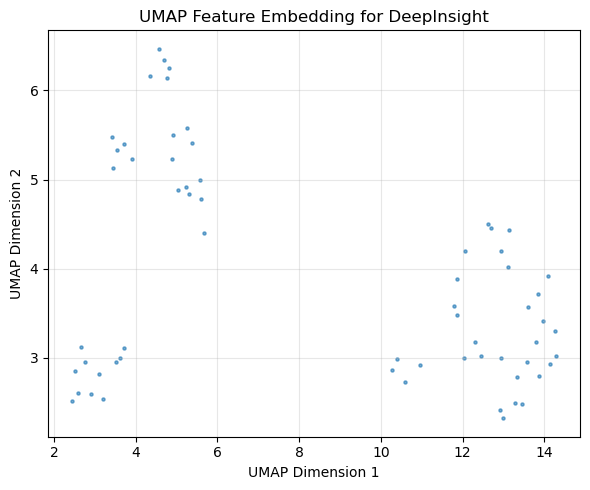

In [18]:
import matplotlib.pyplot as plt

# Assuming reducer was fitted on X_train_normal_tab
embedding = reducer.embedding_

plt.figure(figsize=(6,5))
plt.scatter(embedding[:,0], embedding[:,1], s=5, alpha=0.6)
plt.title("UMAP Feature Embedding for DeepInsight")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\Setha\anaconda3\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


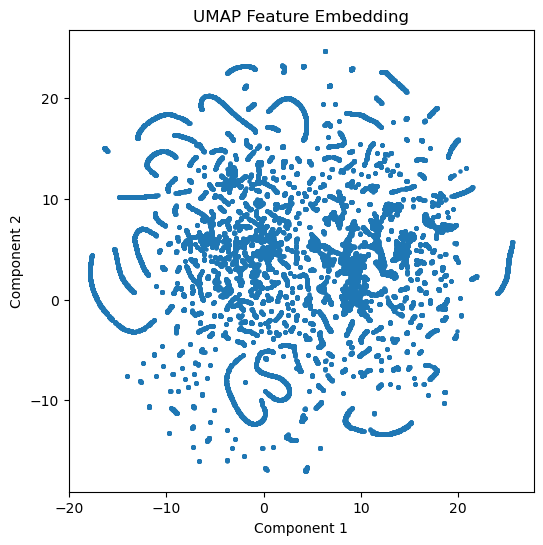

In [28]:
import umap
import matplotlib.pyplot as plt

# UMAP embedding
reducer = umap.UMAP(
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

embedding = reducer.fit_transform(X_train_normal_tab)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(embedding[:, 0], embedding[:, 1], s=5)
plt.title("UMAP Feature Embedding")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()